# Predicting from a continuous connectome, with every fit inside the folds

A connectome predicts a trait only if everything learned from the data is learned without the
subjects it is tested on. For a continuous connectome that includes the functional PCA basis and
the cohort mean it is centred on, as well as the scaling, the model and its penalty; and with
twins and siblings in the cohort, a family has to stay on one side of every split. This notebook
does all of it for 300 HCP young adults and two traits, sex and fluid intelligence (the number
of PMAT24 items answered correctly), from the continuous connectome's component scores and,
beside them, from the Schaefer-200 region matrices of the same files.

`scripts/prediction_data.py` draws the sample family by family, deals the families to five
folds, and fits a rank-15 basis to each fold's training subjects, scoring all 300 on it (about
an hour a fold on the cluster). Everything else happens here, in about 30 minutes on 16 cores
and 5 GB of memory, two thirds of it in section 8, which reruns the whole procedure 2,500
times. The families are restricted HCP data: they are read from outside the repository, and
only counts appear below.

In [1]:
import os

# The model fits are spread over processes, one thread each: a thread count set in the
# environment would be inherited by every process, and their threads would crowd the cores.
# Set before numpy is imported.
for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[name] = "1"

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# The lab's copies on Longleaf; point these at your own files.
ROOT = Path("/work/users/x/y/xya/hcp-ya")
DATA = ROOT / "prediction"  # what scripts/prediction_data.py wrote
TRAITS = ROOT / "open_access_traits.csv"  # subject, sex, age_bin, fluid_intelligence_pmat24
FAMILIES = ROOT / "restricted" / "families.csv"  # restricted HCP data: read here, never shown
FOLDS, RANK = 5, 15

BLUE, ORANGE, INK, MUTED, RULE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#d9d8d3"
plt.rcParams.update({
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": RULE,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": MUTED,
    "ytick.color": MUTED, "figure.facecolor": "white", "figure.dpi": 110,
})

## 1. The sample and its folds

Three hundred subjects in 134 families: 27 alone, 56 pairs, 43 of three and 8 of four. Dealt
whole to five folds of 60, no family has members in two folds. Men are 48% of the sample, and
fluid intelligence averages 16.9 of 24 (sd 4.9). Head size will matter: the brain-mask volume
averages 1.74 L in men and 1.50 L in women.

In [2]:
with open(DATA / "sample.csv", newline="") as handle:
    rows = list(csv.DictReader(handle))
subjects = np.array([row["subject"] for row in rows])
fold = np.array([int(row["fold"]) for row in rows])
with open(TRAITS, newline="") as handle:
    traits = {row["subject"]: row for row in csv.DictReader(handle)}
with open(FAMILIES, newline="") as handle:
    family_of = {row["subject"]: row["group"] for row in csv.DictReader(handle)}
family = np.unique([family_of[s] for s in subjects], return_inverse=True)[1]  # codes 0, 1, ...
del family_of

men = np.array([traits[s]["sex"] == "M" for s in subjects], dtype=int)
pmat = np.array([float(traits[s]["fluid_intelligence_pmat24"]) for s in subjects])
BAND = {"22-25": 23.5, "26-30": 28.0, "31-35": 33.0, "36+": 37.0}
age = np.array([BAND[traits[s]["age_bin"]] for s in subjects])
covariates = np.load(DATA / "covariates.npz")
assert (covariates["subjects"] == subjects).all()
head = np.column_stack([covariates["brain_volume"], covariates["streamlines"]])

sizes = np.bincount(np.bincount(family))
print(f"{subjects.size} subjects in {family.max() + 1} families, of "
      + ", ".join(f"{size} ({count})" for size, count in enumerate(sizes) if size and count)
      + " members (how many families)")
assert all(len(set(fold[family == f])) == 1 for f in range(family.max() + 1))
print(f"{FOLDS} folds of {np.bincount(fold).tolist()} subjects; no family is split between two")
print(f"{men.mean():.0%} men; PMAT24 {pmat.mean():.1f} correct of 24 on average (sd {pmat.std():.1f})")
print(f"brain-mask volume {head[men == 1, 0].mean():.2f} L in men on average, "
      f"{head[men == 0, 0].mean():.2f} L in women")

300 subjects in 134 families, of 1 (27), 2 (56), 3 (43), 4 (8) members (how many families)
5 folds of [60, 60, 60, 60, 60] subjects; no family is split between two
48% men; PMAT24 16.9 correct of 24 on average (sd 4.9)
brain-mask volume 1.74 L in men on average, 1.50 L in women


## 2. Features, each fitted on training subjects alone

For each fold the basis comes from its 240 training subjects alone, and captures 26.0% to 26.4%
of their norm in 15 components; the 60 held-out subjects are scored on it with `sbci.project`,
exactly as the training subjects are. The Schaefer-200 matrices hold each pair of regions' share
of the connectome's unit mass, 19,900 pairs a subject, 9.5% of them zero. They are logged -- one
fixed transform for everyone, with an offset of 1e-9 for the zeros, a choice section 6 shows
hardly matters -- then standardised and reduced by a PCA fitted to each fold's training subjects
alone and scored on everyone, as the components are, so that the two are tuned alike.

In [3]:
position = {subject: i for i, subject in enumerate(subjects)}
component_scores = []
for k in range(FOLDS):
    data = np.load(DATA / f"fold{k}.npz")
    assert set(data["test"]) == set(subjects[fold == k]) and set(data["train"]) == set(subjects[fold != k])
    scores = np.empty((subjects.size, RANK))
    scores[[position[s] for s in data["train"]]] = data["train_scores"]
    scores[[position[s] for s in data["test"]]] = data["test_scores"]
    component_scores.append(scores)  # fold k's basis: every subject scored on it
    print(f"fold {k}: basis from {data['train'].size} subjects, {data['explained'][-1]:.1%} of their norm "
          f"in {RANK} components")

atlas = np.load(DATA / "atlas.npz")
assert (atlas["subjects"] == subjects).all()
masses = atlas["schaefer200"]  # each pair of regions' share of the connectome's unit mass
print(f"Schaefer-200: {masses.shape[1]:,} region pairs a subject, {np.mean(masses == 0):.1%} of them zero")


def region_scores(values, train, standardise=True):
    """A PCA of the region pairs fitted on the training subjects alone, every subject scored on it."""
    steps = [StandardScaler()] if standardise else []
    return make_pipeline(*steps, PCA(n_components=RANK, random_state=0)).fit(values[train]).transform(values)


# Region masses span orders of magnitude, and some are zero: their logarithm, one fixed transform
# for everyone, comes first; the scaling and the PCA are fitted inside each fold, as the basis is.
logged = np.log10(masses + 1e-9)
SCORES = {
    "continuous": component_scores,
    "regions": [region_scores(logged, fold != k) for k in range(FOLDS)],
}

fold 0: basis from 240 subjects, 26.3% of their norm in 15 components
fold 1: basis from 240 subjects, 26.4% of their norm in 15 components
fold 2: basis from 240 subjects, 26.1% of their norm in 15 components
fold 3: basis from 240 subjects, 26.2% of their norm in 15 components
fold 4: basis from 240 subjects, 26.0% of their norm in 15 components


Schaefer-200: 19,900 region pairs a subject, 9.5% of them zero


## 3. One procedure for every model

Every model is fitted the same way. In each of the five outer folds a grid search over a
four-fold split of the training subjects, by family, chooses how many components to use (1 to
15) and the penalty; the scaling is fitted on the training subjects; and the held-out fold is
predicted once. Each fold's AUC or r is computed on its own 60 held-out subjects, and the five
are averaged. Pooled across folds instead, a weak model's r falls below its null -- each fold's
predictions lean towards its training subjects' mean, opposite to its own -- by an amount that
depends on the penalty and on how the subjects were dealt. The cell below shows it with three
features of random numbers, which carry nothing: at a ridge penalty of 100 their pooled r is
-0.099 with families kept whole and -0.051 with them split, and at 10,000 -0.152 and -0.110,
while the per-fold means stay at 0.00 and 0.02. Intervals resample whole families within each
fold, and a difference between two models gets a paired interval, both resampled alike. They
hold each fold's fitted model fixed, and so are too narrow where a model is weak: section 8
measures by how much, and tests the weak results by permutation instead.

In [4]:
class First(BaseEstimator, TransformerMixin):
    """The first k of the leading n columns (component scores), and every column after them."""

    def __init__(self, k=RANK, n=RANK):
        self.k, self.n = k, n

    def fit(self, x, y=None):
        self.n_features_in_ = x.shape[1]  # what marks a scikit-learn step as fitted
        return self

    def transform(self, x):
        return np.hstack([x[:, : self.k], x[:, self.n :]])


COMPONENTS = [1, 2, 3, 5, 8, 10, 15]
PENALTY = {"sex": {"logisticregression__C": np.logspace(-3, 2, 6)},
           "pmat": {"ridge__alpha": np.logspace(-1, 5, 7)}}


def estimator(target):
    return LogisticRegression(max_iter=10_000) if target == "sex" else Ridge()


def predict(scores, target, extra, y, n_jobs=-1):
    """Every subject's prediction from a model chosen, scaled and fitted without its fold.

    ``scores`` holds each fold's component scores (``None`` for the covariates alone), to which
    ``extra`` is added. The outer folds are the sample's, families kept whole; inside each
    training fold a four-fold split by family chooses the number of components and the penalty.
    """
    predicted, chosen = np.empty(y.size), []
    for k in range(FOLDS):
        train, test = fold != k, fold == k
        if scores is None:
            pipeline, grid, x = make_pipeline(StandardScaler(), estimator(target)), PENALTY[target], extra
        else:
            pipeline = make_pipeline(First(), StandardScaler(), estimator(target))
            grid, x = {"first__k": COMPONENTS, **PENALTY[target]}, np.hstack([scores[k], extra])
        search = GridSearchCV(pipeline, grid, cv=GroupKFold(n_splits=4), n_jobs=n_jobs,
                              scoring="roc_auc" if target == "sex" else "r2")
        search.fit(x[train], y[train], groups=family[train])
        predicted[test] = (search.predict_proba(x[test])[:, 1] if target == "sex"
                           else search.predict(x[test]))
        chosen.append({key.split("__")[-1]: value for key, value in search.best_params_.items()})
    return predicted, chosen


def out_of_fold(features, target, extra):
    """The trait's predictions from a named set of features: "covariates" alone, or SCORES' own."""
    y = men if target == "sex" else pmat
    return predict(None if features == "covariates" else SCORES[features], target, extra, y)


def pearson(y, predicted):
    return float(np.corrcoef(y, predicted)[0, 1])


def per_fold(metric, y, predicted, folds=None):
    """The metric in each fold, averaged: pooled across folds, a weak model's r and AUC fall below
    their null, since each fold's predictions lean to its training subjects' mean (shown below)."""
    folds = fold if folds is None else folds
    return float(np.mean([metric(y[folds == k], predicted[folds == k]) for k in range(FOLDS)]))


# Bootstrap draws that resample whole families within each fold, the same draws for every model,
# so that two models' difference has a paired interval.
rng = np.random.default_rng(0)
groups = [[np.flatnonzero(family == f) for f in np.unique(family[fold == k])] for k in range(FOLDS)]
DRAWS = [[np.concatenate([g[i] for i in rng.integers(0, len(g), len(g))]) for g in groups]
         for _ in range(2000)]


def interval(metric, y, first, second=None):
    """A 95% interval for the per-fold mean, or for the first model's less the second's."""
    def at(draw, predicted):
        return np.mean([metric(y[index], predicted[index]) for index in draw])
    values = [at(draw, first) - (at(draw, second) if second is not None else 0.0) for draw in DRAWS]
    return np.percentile(values, [2.5, 97.5])


def chosen_text(chosen):
    """What the inner folds chose in each outer fold: components, and the penalty."""
    penalty = "C" if "C" in chosen[0] else "alpha"
    return "chosen: " + "; ".join((f"{c['k']} at " if "k" in c else "") + f"{penalty} {c[penalty]:g}"
                                  for c in chosen)


def compare(results, y, metric, label, pairs):
    for first, second in pairs:
        difference = per_fold(metric, y, results[first]) - per_fold(metric, y, results[second])
        low, high = interval(metric, y, results[first], results[second])
        print(f"  {first} less {second}: {label} {difference:+.3f} (95% interval {low:+.3f} to {high:+.3f})")

In [5]:
# Why each fold is scored on its own: three features of random numbers, which carry nothing,
# through a ridge regression at four penalties, the folds dealt twenty times with families kept
# whole and twenty times at random.
for alpha in (1e2, 1e3, 1e4, 1e5):
    out = {"whole": [], "split": []}
    for seed in range(20):
        rng = np.random.default_rng(seed)
        x = rng.standard_normal((subjects.size, 3))
        for how, assignment in (("whole", (rng.permutation(family.max() + 1) % FOLDS)[family]),
                                ("split", rng.permutation(subjects.size) % FOLDS)):
            predicted = np.empty(subjects.size)
            for k in range(FOLDS):
                train, test = assignment != k, assignment == k
                fitted = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(x[train], pmat[train])
                predicted[test] = fitted.predict(x[test])
            out[how].append((pearson(pmat, predicted), per_fold(pearson, pmat, predicted, folds=assignment)))
    whole, split = np.array(out["whole"]), np.array(out["split"])
    print(f"random numbers, alpha {alpha:>6g}: pooled r {whole[:, 0].mean():+.3f} with families kept whole, "
          f"{split[:, 0].mean():+.3f} split; per-fold mean {whole[:, 1].mean():+.3f} and {split[:, 1].mean():+.3f}")

random numbers, alpha    100: pooled r -0.099 with families kept whole, -0.051 split; per-fold mean -0.001 and +0.015


random numbers, alpha   1000: pooled r -0.143 with families kept whole, -0.091 split; per-fold mean +0.000 and +0.016


random numbers, alpha  10000: pooled r -0.152 with families kept whole, -0.110 split; per-fold mean +0.001 and +0.016


random numbers, alpha 100000: pooled r -0.152 with families kept whole, -0.111 split; per-fold mean +0.001 and +0.016


## 4. Sex, and how much of it is head size

Sex is predicted mostly by head size here. Brain-mask volume and streamline count alone reach an
AUC of 0.920 (0.881 to 0.956). The continuous components alone reach 0.658 (0.587 to 0.728), and
the Schaefer-200 regions 0.865 (0.819 to 0.907): the regions lead the components by 0.21 (paired
interval 0.12 to 0.29). Added to head size, the components change nothing (-0.011, -0.029 to
+0.005), while the regions add a little, +0.034 (+0.010 to +0.062), to 0.954 -- more than
chance gives: none of the 500 permutations of section 8 reaches it.

In [6]:
none = np.empty((subjects.size, 0))
sex_models = {
    "head size and streamlines": ("covariates", head),
    "continuous": ("continuous", none),
    "continuous, with head size": ("continuous", head),
    "Schaefer-200": ("regions", none),
    "Schaefer-200, with head size": ("regions", head),
}
sex_predicted, sex_chosen, sex_results = {}, {}, {}
for name, (features, extra) in sex_models.items():
    sex_predicted[name], sex_chosen[name] = out_of_fold(features, "sex", extra)
    value = per_fold(roc_auc_score, men, sex_predicted[name])
    low, high = interval(roc_auc_score, men, sex_predicted[name])
    sex_results[name] = (value, low, high)
    print(f"{name:29s} AUC {value:.3f} (95% interval {low:.3f} to {high:.3f}); {chosen_text(sex_chosen[name])}")
compare(sex_predicted, men, roc_auc_score, "AUC", [
    ("continuous, with head size", "head size and streamlines"),
    ("Schaefer-200, with head size", "head size and streamlines"),
    ("Schaefer-200", "continuous"),
])

head size and streamlines     AUC 0.920 (95% interval 0.881 to 0.956); chosen: C 0.001; C 0.1; C 0.1; C 10; C 1


continuous                    AUC 0.658 (95% interval 0.587 to 0.728); chosen: 10 at C 1; 15 at C 0.1; 10 at C 0.1; 10 at C 0.01; 15 at C 100


continuous, with head size    AUC 0.909 (95% interval 0.858 to 0.952); chosen: 3 at C 100; 8 at C 0.1; 5 at C 0.01; 10 at C 1; 1 at C 0.001


Schaefer-200                  AUC 0.865 (95% interval 0.819 to 0.907); chosen: 15 at C 10; 15 at C 1; 15 at C 100; 15 at C 0.01; 15 at C 0.1


Schaefer-200, with head size  AUC 0.954 (95% interval 0.932 to 0.975); chosen: 15 at C 0.1; 10 at C 0.01; 15 at C 0.01; 10 at C 1; 10 at C 0.1


  continuous, with head size less head size and streamlines: AUC -0.011 (95% interval -0.029 to +0.005)


  Schaefer-200, with head size less head size and streamlines: AUC +0.034 (95% interval +0.010 to +0.062)


  Schaefer-200 less continuous: AUC +0.208 (95% interval +0.121 to +0.293)


## 5. Fluid intelligence

Fluid intelligence is not predictable from either connectome in this sample. Sex, age band, head
size and streamline count together give r = 0.335 (0.218 to 0.438), beyond every one of 500
outcomes that carry nothing (section 8). The continuous components alone give 0.038 (-0.082 to
0.155) and the regions 0.044 (-0.083 to 0.164), which a third of those outcomes match
(permutation p 0.33 and 0.32); and added to the covariates neither helps (-0.045, -0.104 to
+0.010; -0.017, -0.071 to +0.036).

In [7]:
demographic = np.column_stack([men, age, head])
pmat_models = {
    "sex, age band, head size, streamlines": ("covariates", demographic),
    "continuous": ("continuous", none),
    "continuous, with those": ("continuous", demographic),
    "Schaefer-200": ("regions", none),
    "Schaefer-200, with those": ("regions", demographic),
}
pmat_predicted, pmat_chosen, pmat_results = {}, {}, {}
for name, (features, extra) in pmat_models.items():
    pmat_predicted[name], pmat_chosen[name] = out_of_fold(features, "pmat", extra)
    value = per_fold(pearson, pmat, pmat_predicted[name])
    low, high = interval(pearson, pmat, pmat_predicted[name])
    pmat_results[name] = (value, low, high)
    print(f"{name:37s} r {value:6.3f} (95% interval {low:6.3f} to {high:6.3f}); {chosen_text(pmat_chosen[name])}")
compare(pmat_predicted, pmat, pearson, "r", [
    ("continuous, with those", "sex, age band, head size, streamlines"),
    ("Schaefer-200, with those", "sex, age band, head size, streamlines"),
    ("Schaefer-200", "continuous"),
])

sex, age band, head size, streamlines r  0.335 (95% interval  0.218 to  0.438); chosen: alpha 10; alpha 10; alpha 10; alpha 10; alpha 10


continuous                            r  0.038 (95% interval -0.082 to  0.155); chosen: 8 at alpha 100; 8 at alpha 100000; 8 at alpha 1000; 5 at alpha 100; 15 at alpha 1000


continuous, with those                r  0.290 (95% interval  0.170 to  0.395); chosen: 8 at alpha 100; 1 at alpha 100; 5 at alpha 10; 5 at alpha 10; 2 at alpha 10


Schaefer-200                          r  0.044 (95% interval -0.083 to  0.164); chosen: 5 at alpha 100; 5 at alpha 100; 15 at alpha 1000; 1 at alpha 100; 3 at alpha 100


Schaefer-200, with those              r  0.318 (95% interval  0.195 to  0.421); chosen: 1 at alpha 10; 5 at alpha 10; 1 at alpha 10; 1 at alpha 10; 3 at alpha 10


  continuous, with those less sex, age band, head size, streamlines: r -0.045 (95% interval -0.104 to +0.010)


  Schaefer-200, with those less sex, age band, head size, streamlines: r -0.017 (95% interval -0.071 to +0.036)


  Schaefer-200 less continuous: r +0.006 (95% interval -0.160 to +0.178)


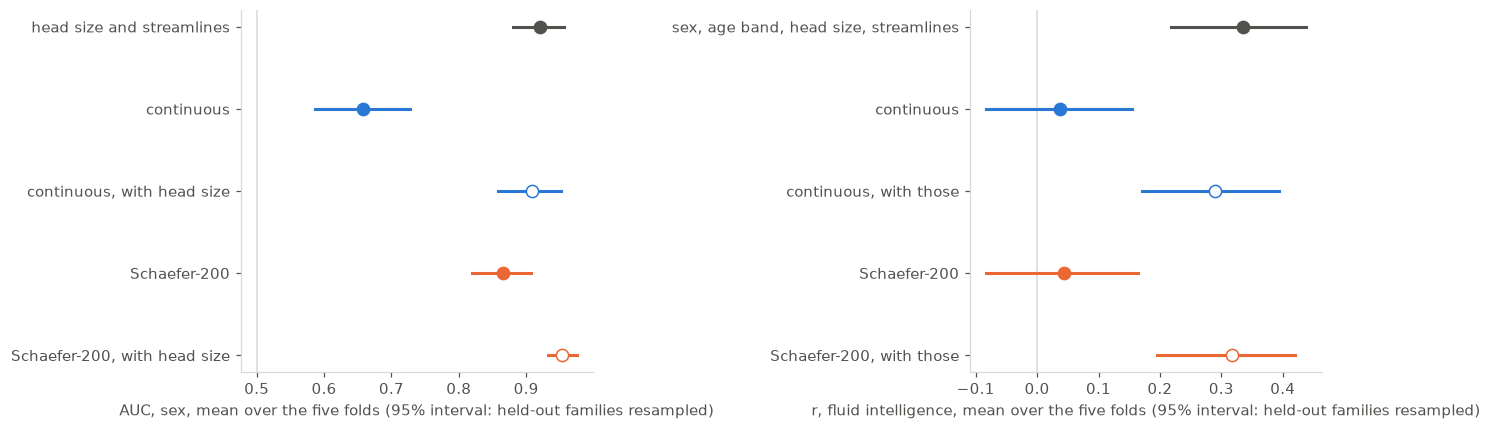

In [8]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
figure.get_layout_engine().set(wspace=0.12)
for axis, results, label, chance in ((left, sex_results, "AUC, sex", 0.5),
                                     (right, pmat_results, "r, fluid intelligence", 0.0)):
    names = list(results)[::-1]
    for row, name in enumerate(names):
        value, low, high = results[name]
        colour = BLUE if name.startswith("continuous") else ORANGE if name.startswith("Schaefer") else MUTED
        axis.plot([low, high], [row, row], color=colour, linewidth=2)
        axis.plot(value, row, "o", color=colour, markersize=8,
                  markerfacecolor="white" if "with" in name else colour)
    axis.axvline(chance, color=RULE, linewidth=1, zorder=0)
    axis.set_yticks(range(len(names)), names)
    axis.set_xlabel(f"{label}, mean over the five folds (95% interval: held-out families resampled)")
plt.show()

## 6. Why the components trail the regions

Most of the regions' lead on sex is the reduction, not the transform. The regions' masses are
logged and standardised before their PCA, where the functional PCA takes the continuous densities
as they are, weighed by the surface's areas. The regions' counterpart of that -- each pair's
density, its mass over the product of the two regions' areas, weighted by those areas, and each
region with itself included -- reaches 0.806 (0.752 to 0.854). So the transform may be worth
about 0.06 (paired interval 0.000 to 0.119, and held to fixed models, if anything too narrow),
and the reductions themselves 0.148 (0.083 to 0.212): fifteen separable components of the
vertex-level densities -- each a product of one surface map with itself, fitted to reconstruct
the connectome -- against a PCA of the region-level ones, which weighs 20,100 values in any
direction. Fifteen such components carry less of what tells the sexes apart. The offset the
logarithm needs for the zero masses hardly matters: the AUC is 0.865 for every offset from
1e-12 to 1e-9, and falls only as the offset nears the median mass, to 0.861 at 1e-8 and 0.840
at 1e-6.

In [9]:
# The functional PCA takes the continuous densities as they are, in the inner product the
# surface's areas give. Its counterpart on the regions: each region pair's density -- its mass over
# the product of the two regions' areas -- weighted by those areas, and each region with itself
# included, as the functional PCA includes the vertex pairs within a region.
area, within_area = atlas["schaefer200_area"], atlas["schaefer200_within_area"]
pair = np.triu_indices(area.size, 1)  # the order of the masses' columns
densities = np.hstack([np.sqrt(2) * masses / np.sqrt(area[pair[0]] * area[pair[1]]),
                       atlas["schaefer200_within"] / np.sqrt(within_area)])
SCORES["densities"] = [region_scores(densities, fold != k, standardise=False) for k in range(FOLDS)]
alike, _ = out_of_fold("densities", "sex", none)
value = per_fold(roc_auc_score, men, alike)
low, high = interval(roc_auc_score, men, alike)
print(f"Schaefer-200, a PCA of the region densities as the functional PCA weighs them: sex AUC {value:.3f} "
      f"(95% interval {low:.3f} to {high:.3f})")
compare({"logged and standardised": sex_predicted["Schaefer-200"], "densities": alike,
         "the continuous components": sex_predicted["continuous"]}, men, roc_auc_score, "AUC",
        [("logged and standardised", "densities"), ("densities", "the continuous components")])

# The logarithm needs an offset for the masses that are zero; how much the choice matters.
for offset in (1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6):
    SCORES["offset"] = [region_scores(np.log10(masses + offset), fold != k) for k in range(FOLDS)]
    predicted, _ = out_of_fold("offset", "sex", none)
    print(f"log10(mass + {offset:g}): sex AUC {per_fold(roc_auc_score, men, predicted):.3f}")

Schaefer-200, a PCA of the region densities as the functional PCA weighs them: sex AUC 0.806 (95% interval 0.752 to 0.854)


  logged and standardised less densities: AUC +0.060 (95% interval +0.000 to +0.119)


  densities less the continuous components: AUC +0.148 (95% interval +0.083 to +0.212)


log10(mass + 1e-12): sex AUC 0.865


log10(mass + 1e-10): sex AUC 0.865


log10(mass + 1e-09): sex AUC 0.865


log10(mass + 1e-08): sex AUC 0.861


log10(mass + 1e-07): sex AUC 0.851


log10(mass + 1e-06): sex AUC 0.840


## 7. What keeping families whole is for

Keeping families whole matters where a trait runs in families. The subjects are dealt to folds
twenty times with families kept whole and twenty times at random, which splits 94 of the 134
families on average, and one fixed model -- all fifteen components, with a penalty set in
advance -- is scored both ways. For fluid intelligence, splitting families raises the per-fold
r by 0.045 on average, from 0.072 to 0.117 (sd 0.042 over the dealings, a standard error of
0.009): twins and siblings on both sides of a split pass the model a little of each other's
score. The control is the same masses with each pair's values shuffled across subjects, afresh
for each dealing, then scaled and reduced as the regions are; it moves by +0.017 (sd 0.061, a
standard error of 0.014), within chance of nothing. For sex the regions score alike both ways
(+0.004), and the shuffled masses sit at chance, 0.49 and 0.51.

In [10]:
def dealt_scores(assignment, values):
    """Each fold's PCA scores of ``values``, scaled and fitted on that fold's training subjects."""
    return [region_scores(values, assignment != k) for k in range(FOLDS)]


def dealt_folds(assignment, target, scores, penalty):
    """Per-fold mean of a fixed model -- all fifteen components and one penalty -- over one dealing."""
    y = men if target == "sex" else pmat
    predicted = np.empty(y.size)
    for k in range(FOLDS):
        train, test = assignment != k, assignment == k
        model = (LogisticRegression(C=penalty, max_iter=10_000) if target == "sex" else Ridge(alpha=penalty))
        fitted = make_pipeline(StandardScaler(), model).fit(scores[k][train], y[train])
        predicted[test] = (fitted.predict_proba(scores[k][test])[:, 1] if target == "sex"
                           else fitted.predict(scores[k][test]))
    metric = roc_auc_score if target == "sex" else pearson
    return per_fold(metric, y, predicted, folds=assignment)


REPEATS = 20
FIXED = {"sex": ("C", 1.0), "pmat": ("alpha", 100.0)}  # set in advance, the middle of the grids


def one_dealing(seed, logged):
    """Both feature sets, both ways of dealing and both traits, for one draw of the folds."""
    rng = np.random.default_rng(seed)
    kept = (rng.permutation(family.max() + 1) % FOLDS)[family]  # each family to a fold at random
    shuffled = rng.permutation(subjects.size) % FOLDS  # each subject, families ignored
    # Features with nothing to leak, made and processed as the regions are: the same logged masses,
    # each pair's values shuffled across subjects afresh for each dealing, then scaled and reduced
    # inside each fold.
    control = np.random.default_rng(1000 + seed).permuted(logged, axis=0)
    straddle = sum(len(set(shuffled[family == f])) > 1 for f in range(family.max() + 1))
    values = {}
    for features, x in (("Schaefer-200", logged), ("shuffled masses", control)):
        for how, assignment in (("whole", kept), ("split", shuffled)):
            scores = dealt_scores(assignment, x)
            for target in ("sex", "pmat"):
                values[target, features, how] = dealt_folds(assignment, target, scores, FIXED[target][1])
    return straddle, values


dealings = Parallel(n_jobs=-1)(delayed(one_dealing)(seed, logged) for seed in range(REPEATS))
print(f"split at random, {np.mean([straddle for straddle, _ in dealings]):.0f} of the {family.max() + 1} "
      "families straddle folds on average")
for target, label in (("sex", "sex, AUC"), ("pmat", "fluid intelligence, r")):
    key, penalty = FIXED[target]
    for features in ("Schaefer-200", "shuffled masses"):
        whole = np.array([values[target, features, "whole"] for _, values in dealings])
        split = np.array([values[target, features, "split"] for _, values in dealings])
        gap = split - whole
        print(f"{label:22s} from {features:15s} (all {RANK} components, {key} {penalty:g}): "
              f"{whole.mean():.3f} with families kept whole, {split.mean():.3f} with them split; "
              f"split less whole {gap.mean():+.3f} (sd {gap.std():.3f} over {REPEATS} dealings)")

split at random, 94 of the 134 families straddle folds on average
sex, AUC               from Schaefer-200    (all 15 components, C 1): 0.852 with families kept whole, 0.856 with them split; split less whole +0.004 (sd 0.013 over 20 dealings)
sex, AUC               from shuffled masses (all 15 components, C 1): 0.490 with families kept whole, 0.506 with them split; split less whole +0.016 (sd 0.044 over 20 dealings)
fluid intelligence, r  from Schaefer-200    (all 15 components, alpha 100): 0.072 with families kept whole, 0.117 with them split; split less whole +0.045 (sd 0.042 over 20 dealings)
fluid intelligence, r  from shuffled masses (all 15 components, alpha 100): -0.023 with families kept whole, -0.006 with them split; split less whole +0.017 (sd 0.061 over 20 dealings)


## 8. How far to trust the intervals

The intervals above resample the held-out families with each fold's fitted model held fixed.
They leave out how the models would have come out with other training families, and that every
two folds' models share three quarters of their training subjects. Rerunning the whole procedure
on 500 outcomes that carry nothing -- fluid intelligence moved a whole family at a time onto
another family of the same size, which keeps its family structure and breaks its every link to
the features -- shows what that costs. There the per-fold r of each of the three
fluid-intelligence models spreads with an sd of 0.083 to 0.085, where the bootstrap gives 0.059
or 0.060, and the "95%" interval leaves out zero for 16% to 17% of the outcomes rather than 5%:
a weak model's interval is too narrow by about a third. (For the two connectome models a
bootstrap that refits every model on the resampled families overshoots instead, to about 0.10,
because a resampled training fold repeats families and so holds fewer distinct ones; for head
size and sex the two bootstraps agree. `tests/reference/tenth_list_probe.py` measures it.)

The same permutations give exact tests. The covariates' r of 0.335 is beyond all 500 (p =
0.002, the least 500 permutations can give); the continuous components' 0.038 and the regions'
0.044 are matched by a third of them (p = 0.33 and 0.32). For sex, what a connectome adds to head
size is tested by keeping the part of its scores that head size and streamline count predict and
moving the rest, family by family: what the connectome then adds, it adds by chance, -0.003 and
-0.004 on average (sd 0.004 and 0.005). The regions' +0.034 is beyond all 500 (p = 0.002); the
components' -0.011 is below nearly all of them (p = 0.95).

In [11]:
# The intervals above hold each fold's fitted model fixed and resample only who is tested. What
# that leaves out shows when the whole procedure is rerun on outcomes that carry nothing: fluid
# intelligence moved a whole family at a time onto another family of the same size, which keeps
# its family structure and breaks its every link to the features.
members = [np.flatnonzero(family == f) for f in range(family.max() + 1)]


def family_permutation(rng):
    """A reordering of the subjects that moves whole families onto families of the same size."""
    order = np.arange(subjects.size)
    for size in sorted({len(m) for m in members}):
        same = [m for m in members if len(m) == size]
        for onto, source in zip(same, rng.permutation(len(same))):
            order[onto] = same[source]
    return order


PERMUTATIONS = 500
orders = [family_permutation(np.random.default_rng(1000 + i)) for i in range(PERMUTATIONS)]

# The bootstrap's per-fold mean r in every draw at once, from each draw's count of every subject:
# the same numbers as resampling them one draw at a time, as interval() does.
held_out = [np.flatnonzero(fold == k) for k in range(FOLDS)]
COUNTS = [np.stack([np.bincount(np.searchsorted(held_out[k], draw[k]), minlength=held_out[k].size)
                    for draw in DRAWS]).astype(float) for k in range(FOLDS)]


def bootstrap_r(y, predicted):
    values = np.zeros(len(DRAWS))
    for k, counts in enumerate(COUNTS):
        a, b, n = y[held_out[k]], predicted[held_out[k]], counts.sum(axis=1)
        # Standardised first, which leaves r as it is: a heavily penalised model's predictions
        # barely vary, and raw sums of them would cancel to nothing in the subtractions below.
        a, b = (a - a.mean()) / a.std(), (b - b.mean()) / b.std()
        sa, sb = counts @ a, counts @ b
        values += (n * (counts @ (a * b)) - sa * sb) / np.sqrt(
            (n * (counts @ (a * a)) - sa**2) * (n * (counts @ (b * b)) - sb**2))
    return values / FOLDS


check = pmat_predicted["continuous"]
assert np.allclose(np.percentile(bootstrap_r(pmat, check), [2.5, 97.5]), interval(pearson, pmat, check))

null = {}
for name, scores, extra in (("sex, age band, head size, streamlines", None, demographic),
                            ("continuous", SCORES["continuous"], none),
                            ("Schaefer-200", SCORES["regions"], none)):
    runs = Parallel(n_jobs=-1)(delayed(predict)(scores, "pmat", extra, pmat[order], 1) for order in orders)
    r = np.array([per_fold(pearson, pmat[order], predicted) for order, (predicted, _) in zip(orders, runs)])
    draws = [bootstrap_r(pmat[order], predicted) for order, (predicted, _) in zip(orders, runs)]
    low, high = np.array([np.percentile(values, [2.5, 97.5]) for values in draws]).T
    observed = pmat_results[name][0]
    null[name] = r
    print(f"{name:37s} under the null: r {r.mean():+.3f} on average, sd {r.std():.3f}, where the bootstrap "
          f"gives {np.mean([values.std() for values in draws]):.3f}; its 95% interval left out 0 for "
          f"{np.mean((low > 0) | (high < 0)):.0%} of the outcomes. Observed r {observed:.3f}: permutation "
          f"p {(1 + np.sum(r >= observed)) / (1 + PERMUTATIONS):.3f}")

sex, age band, head size, streamlines under the null: r -0.004 on average, sd 0.085, where the bootstrap gives 0.060; its 95% interval left out 0 for 16% of the outcomes. Observed r 0.335: permutation p 0.002


continuous                            under the null: r -0.000 on average, sd 0.083, where the bootstrap gives 0.059; its 95% interval left out 0 for 17% of the outcomes. Observed r 0.038: permutation p 0.331


Schaefer-200                          under the null: r +0.006 on average, sd 0.084, where the bootstrap gives 0.059; its 95% interval left out 0 for 16% of the outcomes. Observed r 0.044: permutation p 0.323


In [12]:
# For sex the question is what a connectome adds to head size. Head size and streamline count
# explain part of each fold's scores; the rest is moved by whole families, as above, and the
# procedure rerun -- so what the connectome then adds, it adds by chance.
design = np.column_stack([np.ones(subjects.size), head])
baseline = sex_results["head size and streamlines"][0]


def head_and_rest(scores):
    """Each fold's scores split into what head size and streamline count predict, and the rest."""
    parts = []
    for fold_scores in scores:
        fitted = design @ np.linalg.lstsq(design, fold_scores, rcond=None)[0]
        parts.append((fitted, fold_scores - fitted))
    return parts


def added(parts, order):
    predicted, _ = predict([fitted + rest[order] for fitted, rest in parts], "sex", head, men, n_jobs=1)
    return per_fold(roc_auc_score, men, predicted) - baseline


for name, features in (("continuous", "continuous"), ("Schaefer-200", "regions")):
    parts = head_and_rest(SCORES[features])
    chance = np.array(Parallel(n_jobs=-1)(delayed(added)(parts, order) for order in orders))
    observed = sex_results[f"{name}, with head size"][0] - baseline
    print(f"{name} added to head size: AUC {observed:+.3f}, where by chance it adds {chance.mean():+.3f} on "
          f"average (sd {chance.std():.3f}); permutation p {(1 + np.sum(chance >= observed)) / (1 + PERMUTATIONS):.3f}")

continuous added to head size: AUC -0.011, where by chance it adds -0.003 on average (sd 0.004); permutation p 0.950


Schaefer-200 added to head size: AUC +0.034, where by chance it adds -0.004 on average (sd 0.005); permutation p 0.002


## What this says

- **Fit everything inside the training folds, keep families whole, and score each fold on its
  own.** Splitting families raised fluid intelligence's r by 0.045 on average, a small leak but
  a systematic one; pooled across folds, a weak model's r sits below its null, by an amount that
  depends on the dealing and the penalty.
- **Check what the covariates alone do.** Sex here is head size first (AUC 0.92); the regions
  add a little to it (+0.034, permutation p 0.002), the components nothing.
- **Test weak results by permutation.** Resampling the held-out families with the fitted models
  held fixed gives intervals too narrow by about a third where a model is weak; neither
  connectome predicts fluid intelligence better than chance (p 0.33 and 0.32).
- **At rank 15 the continuous components carry less about sex than a parcellation's PCA** (AUC
  0.66 against 0.87): a PCA of the region densities, weighed as the functional PCA weighs the
  continuous ones, still reaches 0.81, so most of the gap is the reduction, not the transform.